In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Caso 2

# 2. Caso: Factores que Impactan el Desempeño en Matemáticas

# 2.1 Contexto

Una universidad ha recopilado información sobre el desempeño de sus estudiantes en matemáticas con el objetivo
de identificar los factores que más influyen en su rendimiento. Se busca entender cómo aspectos como el tiempo
de estudio, la asistencia a actividades extracurriculares y las horas de sueño inciden en el puntaje final.

A través del análisis de datos de estudiantes universitarios, se espera:

- Evaluar la relación entre el tiempo de estudio y las calificaciones finales.

- Identificar diferencias de desempeño según la asistencia a actividades extracurriculares.

- Aplicar modelos de regresión para predecir el rendimiento académico y entender sus principales determinantes.

## 2.2 Análisis exploratorio de datos

In [ ]:
df=pd.read_csv('https://raw.githubusercontent.com/daramireh/simonBolivarCienciaDatos/refs/heads/main/Student_Performance.csv')

In [24]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [20]:
df.describe().round(3)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000,10000.000,10000.000,10000.000,10000.000
mean,4.993,69.446,6.531,4.583,55.225
std,2.589,17.343,1.696,2.867,19.213
min,1.000,40.000,4.000,0.000,10.000
25%,3.000,54.000,5.000,2.000,40.000
50%,5.000,69.000,7.000,5.000,55.000
75%,7.000,85.000,8.000,7.000,71.000
max,9.000,99.000,9.000,9.000,100.000


In [25]:
df['Extracurricular Activities'].value_counts()

Extracurricular Activities
No     5052
Yes    4948
Name: count, dtype: int64

In [72]:
VAR_DISC = ["Hours Studied", "Sleep Hours", "Sample Question Papers Practiced"]
VAR_CONT = ["Previous Scores"]
VAR_CAT  = "Extracurricular Activities"
VAR_TGT  = "Performance Index"

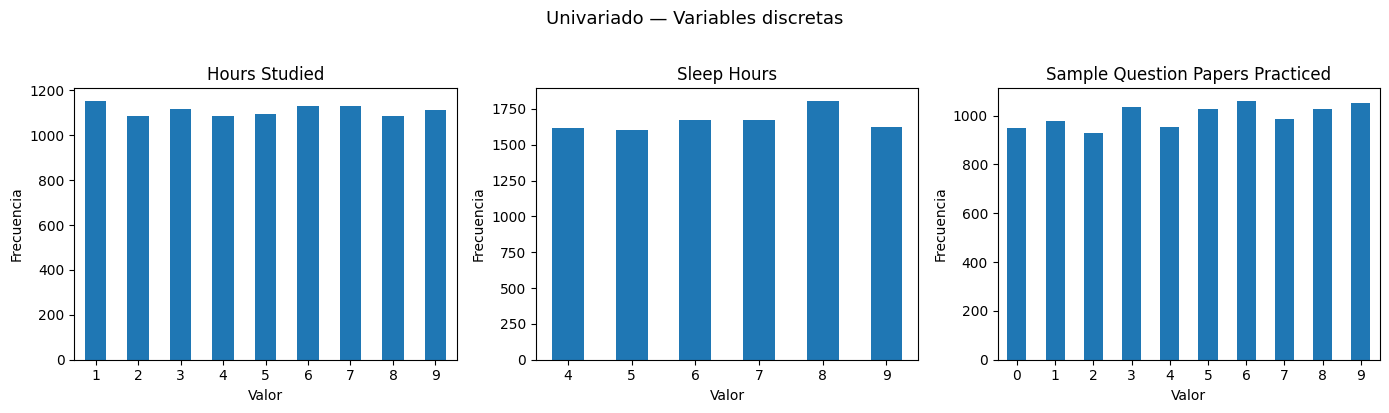

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, var in zip(axes, VAR_DISC):
    df[var].value_counts().sort_index().plot(kind="bar", ax=ax, rot=0)
    ax.set_title(var)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")

plt.suptitle("Univariado — Variables discretas", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


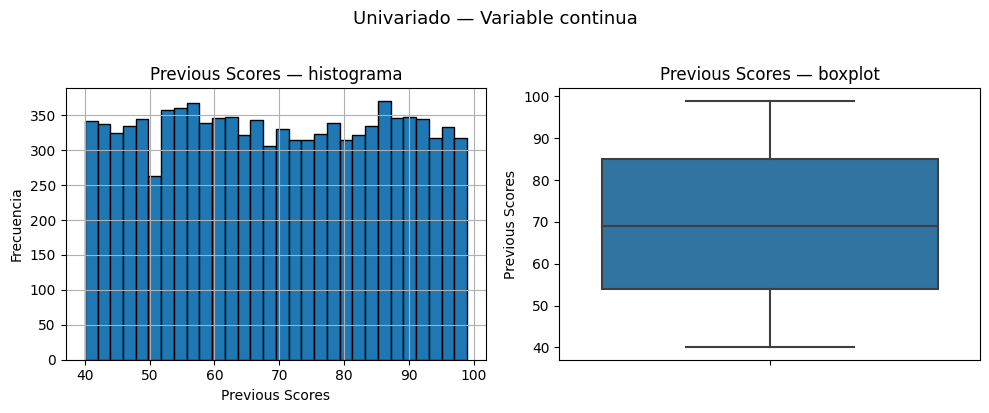

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["Previous Scores"].hist(bins=30, ax=axes[0], edgecolor="black")
axes[0].set_title("Previous Scores — histograma")
axes[0].set_xlabel("Previous Scores")
axes[0].set_ylabel("Frecuencia")

sns.boxplot(y=df["Previous Scores"])
axes[1].set_title("Previous Scores — boxplot")

plt.suptitle("Univariado — Variable continua", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


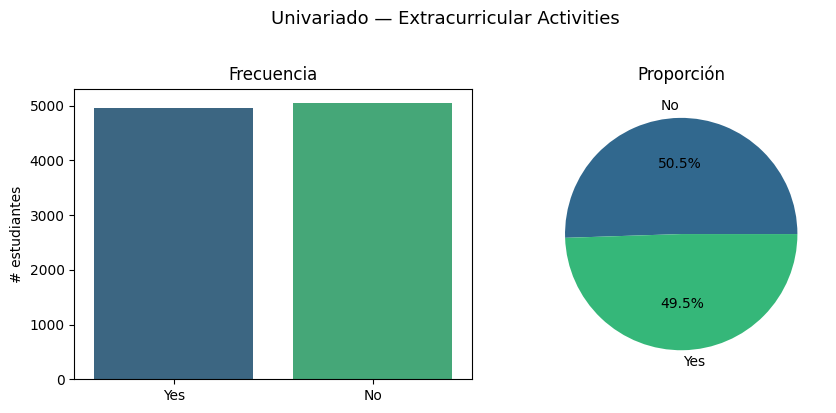

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

sns.countplot(x=VAR_CAT, data=df, ax=axes[0], palette='viridis')
axes[0].set_title("Frecuencia")
axes[0].set_ylabel("# estudiantes")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)


counts = df[VAR_CAT].value_counts()
axes[1].pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    counterclock=True,
    colors=sns.color_palette('viridis', len(counts))
)
axes[1].set_title("Proporción")

plt.suptitle("Univariado — Extracurricular Activities", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

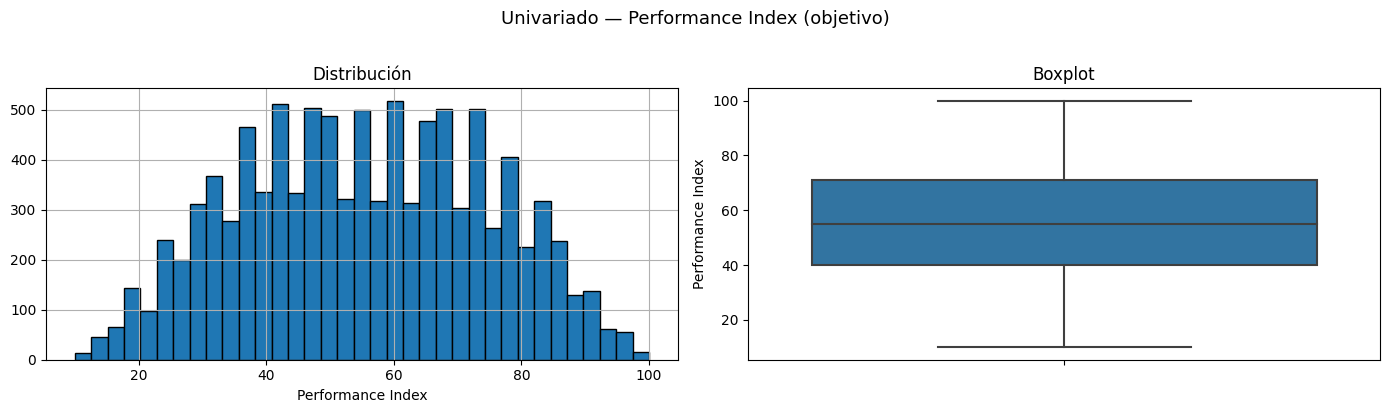

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[VAR_TGT].hist(bins=35, ax=axes[0], edgecolor="black")
axes[0].set_title("Distribución")
axes[0].set_xlabel(VAR_TGT)

sns.boxplot(y=df[VAR_TGT], ax=axes[1])
axes[1].set_title("Boxplot")


plt.suptitle("Univariado — Performance Index (objetivo)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


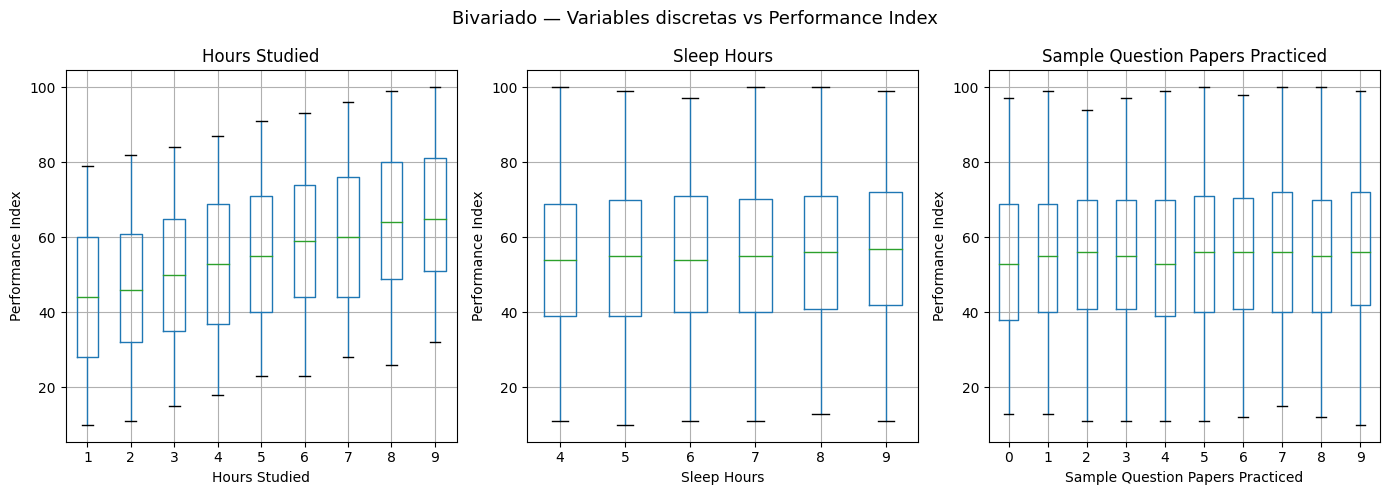

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, var in zip(axes, VAR_DISC):
    df.boxplot(column=VAR_TGT, by=var, ax=ax)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel(VAR_TGT)

plt.suptitle("Bivariado — Variables discretas vs Performance Index", fontsize=13)
plt.tight_layout()
plt.show()


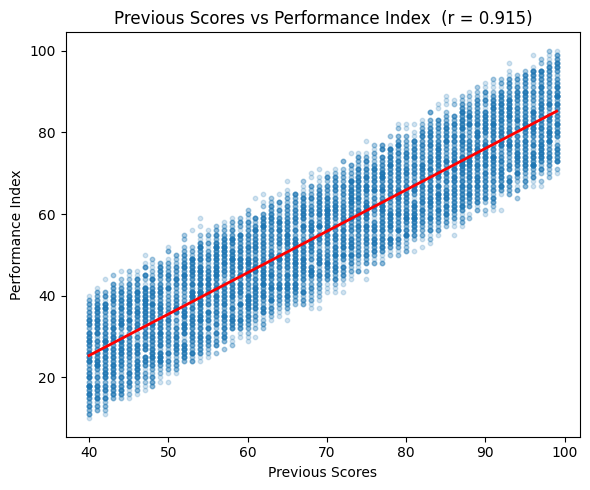

In [95]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(df["Previous Scores"], df[VAR_TGT], alpha=0.2, s=10)

m, b, r, p, _ = stats.linregress(df["Previous Scores"].dropna(),
                                  df[VAR_TGT].dropna())
x = np.linspace(df["Previous Scores"].min(), df["Previous Scores"].max(), 100)
ax.plot(x, m * x + b, color="red", lw=2)

ax.set_title(f"Previous Scores vs Performance Index  (r = {r:.3f})")
ax.set_xlabel("Previous Scores")
ax.set_ylabel(VAR_TGT)

plt.tight_layout()
plt.show()


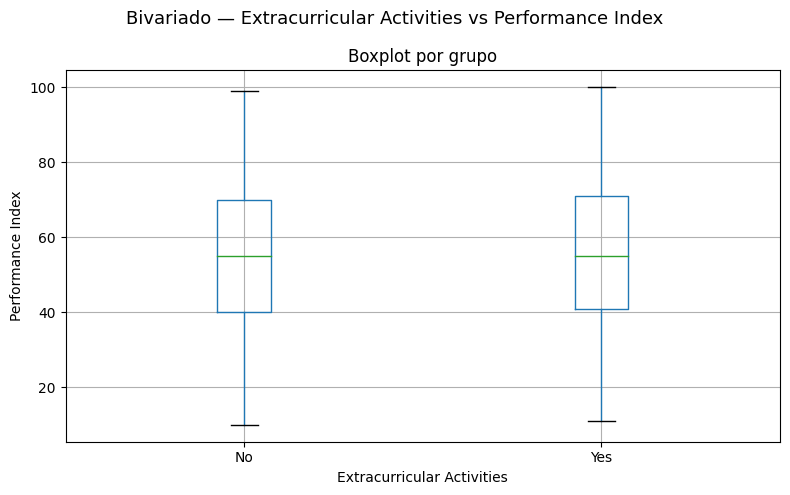

In [96]:
fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(column=VAR_TGT, by=VAR_CAT, ax=ax)
ax.set_title("Boxplot por grupo")
ax.set_xlabel(VAR_CAT)
ax.set_ylabel(VAR_TGT)

plt.suptitle("Bivariado — Extracurricular Activities vs Performance Index", fontsize=13)
plt.tight_layout()
plt.show()

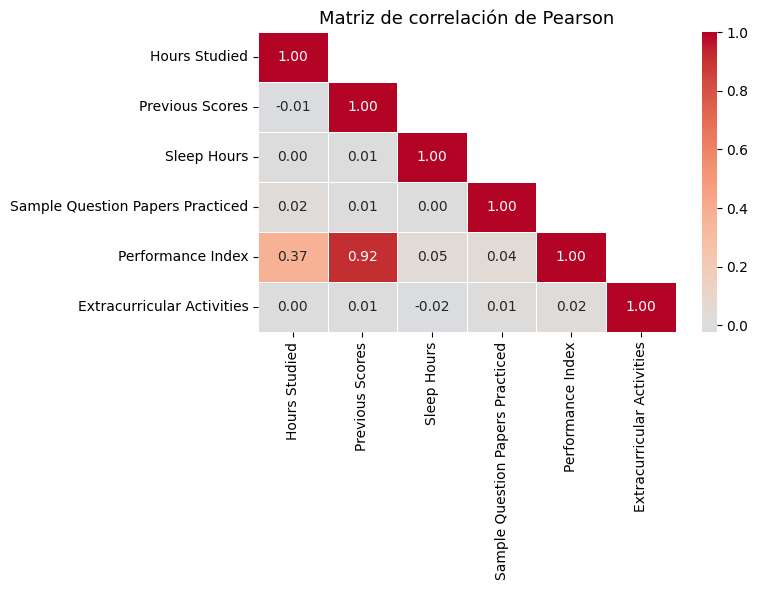

In [99]:
df_corr = df.copy()
df_corr["Extracurricular Activities"] = (df[VAR_CAT] == "Yes").astype(int)

corr = df_corr.drop(columns=["Extracurricular Activities"]).join(
       df_corr["Extracurricular Activities"]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de correlación de Pearson", fontsize=13)
plt.tight_layout()
plt.show()



Debido a la alta correlación que existe entre el score del examen previo al examen actual, se espera que los modelos lineales sean suficientes para resolver la tarea de regresión y clasificación.

¿Existen diferencias estadísticas entre el puntaje final (Performance Index) y la asistencia a actividades extracurriculares?

In [100]:
grupo_yes = df.loc[df[VAR_CAT] == "Yes", VAR_TGT]
grupo_no  = df.loc[df[VAR_CAT] == "No",  VAR_TGT]

print(f"n Yes : {len(grupo_yes)}")
print(f"n No  : {len(grupo_no)}")
print(f"Media Yes : {grupo_yes.mean():.4f}")
print(f"Media No  : {grupo_no.mean():.4f}")
print(f"Diferencia de medias: {grupo_yes.mean() - grupo_no.mean():.4f}")


n Yes : 4948
n No  : 5052
Media Yes : 55.7009
Media No  : 54.7585
Diferencia de medias: 0.9424


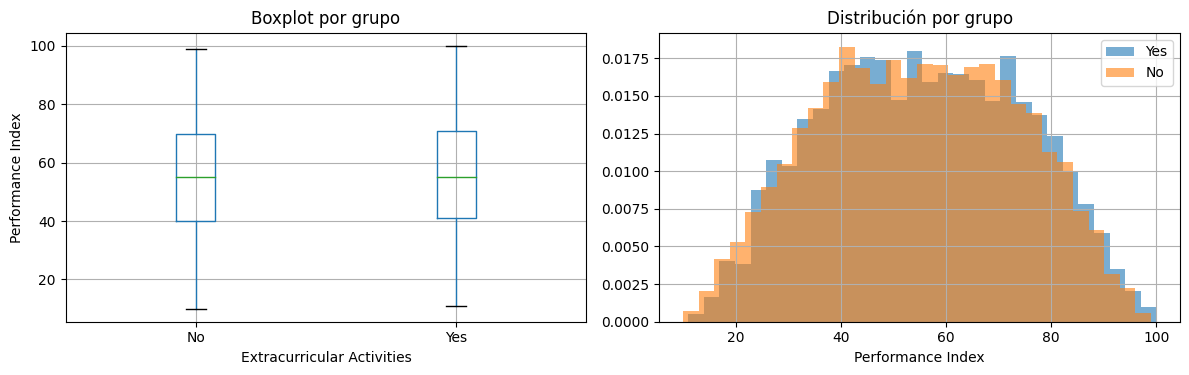

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(column=VAR_TGT, by=VAR_CAT, ax=axes[0])
axes[0].set_title("Boxplot por grupo")
axes[0].set_xlabel(VAR_CAT)
axes[0].set_ylabel(VAR_TGT)

for grupo, label in [(grupo_yes, "Yes"), (grupo_no, "No")]:
    grupo.hist(bins=30, alpha=0.6, ax=axes[1], label=label, density=True)
axes[1].set_title("Distribución por grupo")
axes[1].set_xlabel(VAR_TGT)
axes[1].legend()

plt.suptitle("")
plt.tight_layout()
plt.show()


Para comprobar si existen diferencias significativas en las notas de los estudiantes que asisten a actividades extracurriculares y los que no, debemos hacer una prueba estadística, y para determinar cual usar, hay que determinar si ambos grupos a comparar siguen una distribución normal.

Para la prueba de normalidad se usa Kolmogorov-Smirnov debido a que ambos grupos tienen más de 50 elementos.



- H₀: No existe diferencia en el Performance Index entre estudiantes con y sin actividades extracurriculares (μ_Yes = μ_No)

- H₁: Sí existe diferencia (μ_Yes ≠ μ_No)

Nivel de significancia: α = 0.05

Si p > 0.05, no se rechaza normalidad 

Si p ≤ 0.05, se rechaza normalidad y se debe usar una prueba no paramétrica

In [102]:
ks_yes, p_yes = stats.kstest(grupo_yes, "norm",
                              args=(grupo_yes.mean(), grupo_yes.std()))
ks_no,  p_no  = stats.kstest(grupo_no,  "norm",
                              args=(grupo_no.mean(),  grupo_no.std()))

print("── Kolmogorov-Smirnov ──────────────────────")
print(f"Grupo Yes  →  KS = {ks_yes:.4f},  p = {p_yes:.4f}")
print(f"Grupo No   →  KS = {ks_no:.4f},  p = {p_no:.4f}")

normalidad_yes = p_yes > 0.05
normalidad_no  = p_no  > 0.05
print(f"\nNormalidad Yes : {'Sigue la distribución normal' if normalidad_yes else 'No sigue la distribución normal'}")
print(f"Normalidad No  : {'Sigue la distribución normal' if normalidad_no  else 'No sigue la distribución normal'}")


── Kolmogorov-Smirnov ──────────────────────
Grupo Yes  →  KS = 0.0492,  p = 0.0000
Grupo No   →  KS = 0.0452,  p = 0.0000

Normalidad Yes : No sigue la distribución normal
Normalidad No  : No sigue la distribución normal


Dado que ninguno de los dos grupos sigue una distribución normal, se usará la prueba no paramétrica Mann-Withney U para determinar si existe diferencia significativa entre ambos grupos.

In [103]:
print("── Prueba de hipótesis ──────────────────────")


prueba = "Mann-Whitney U (no paramétrica)"
stat, p_valor = stats.mannwhitneyu(grupo_yes, grupo_no,
                                        alternative="two-sided")

print(f"Prueba aplicada : {prueba}")
print(f"Estadístico     : {stat:.4f}")
print(f"p-value         : {p_valor:.4f}")
print()

if p_valor < 0.05:
    print("Se rechaza la hipótesis nula — sí existe diferencia estadísticamente significativa")
else:
    print("No se rechaza la hipótesis nula — no hay evidencia de diferencia significativa")


── Prueba de hipótesis ──────────────────────
Prueba aplicada : Mann-Whitney U (no paramétrica)
Estadístico     : 12814910.5000
p-value         : 0.0284

Se rechaza la hipótesis nula — sí existe diferencia estadísticamente significativa


Veamos qué tan importante es esta diferencia con el test de la d de Cohen.

Tamaño del efecto — Cohen's d

El p-value solo indica si hay diferencia. Cohen's d indica **qué tan grande** es esa diferencia.

| Cohen's d | Interpretación |
|---|---|
| < 0.2 | Efecto despreciable |
| 0.2 – 0.5 | Efecto pequeño |
| 0.5 – 0.8 | Efecto mediano |
| > 0.8 | Efecto grande |


In [105]:
n1, n2   = len(grupo_yes), len(grupo_no)
s_pooled = np.sqrt(((n1-1)*grupo_yes.std()**2 + (n2-1)*grupo_no.std()**2) / (n1+n2-2))
cohen_d  = (grupo_yes.mean() - grupo_no.mean()) / s_pooled

print(f"Cohen's d = {cohen_d:.4f}")

if abs(cohen_d) < 0.2:
    print("Efecto despreciable")
elif abs(cohen_d) < 0.5:
    print("Efecto pequeño")
elif abs(cohen_d) < 0.8:
    print("Efecto mediano")
else:
    print("Efecto grande")


Cohen's d = 0.0491
Efecto despreciable


## 2.3 Modelado predictivo con Machine Learning

In [109]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, r2_score,
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, RocCurveDisplay
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [107]:
# Codificación de la variable categórica
df["Extracurricular Activities"] = (df["Extracurricular Activities"] == "Yes").astype(int)

FEATURES = df.columns.drop("Performance Index")

In [128]:
#Target regresión
y_reg = df["Performance Index"]

#Target clasificación
umbral = 60
df["bajo_rendimiento"] = (df["Performance Index"] < umbral).astype(int)
y_clf = df["bajo_rendimiento"]

print(f"Umbral: {umbral:.2f}")
print(f"\nDistribución del target de clasificación:")
print(y_clf.value_counts().rename({0: "Normal/Alto (0)", 1: "Bajo rendimiento (1)"}))
print(f"\nProporción bajo rendimiento: {y_clf.mean():.2%}")


Umbral: 60.00

Distribución del target de clasificación:
bajo_rendimiento
Bajo rendimiento (1)    5710
Normal/Alto (0)         4290
Name: count, dtype: int64

Proporción bajo rendimiento: 57.10%


Escogí el umbral de clasificación como el valor 60 ya que en general en Colombia este es el umbral definido por las universidades para establecer un mal rendimiento de un estudiante en una materia o en el pregrado en general.

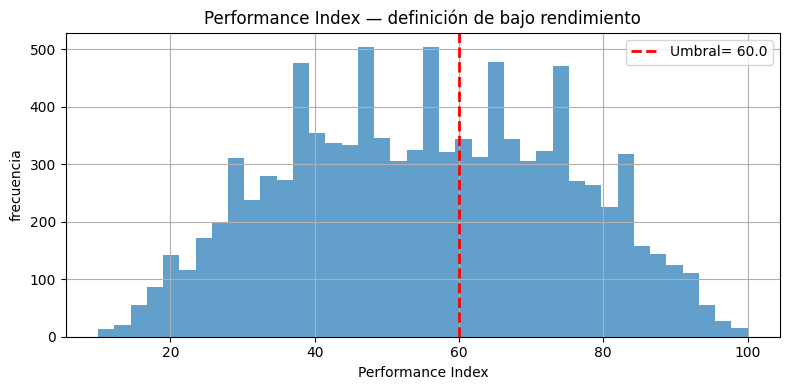

In [129]:
# Visualización del corte sobre la distribución
plt.figure(figsize=(8, 4))
df["Performance Index"].hist(bins=40, alpha=0.7)
plt.axvline(umbral, color="red", lw=2, ls="--",
            label=f"Umbral= {umbral:.1f}")
plt.title("Performance Index — definición de bajo rendimiento")
plt.xlabel("Performance Index")
plt.ylabel("frecuencia")
plt.legend()
plt.tight_layout()
plt.show()


In [112]:
X = df[FEATURES]

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

X_train_c, X_test_c, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f"Train: {X_train.shape[0]} filas  |  Test: {X_test.shape[0]} filas")
print(f"Proporción bajo rendimiento — Train: {y_clf_train.mean():.2%}  |  Test: {y_clf_test.mean():.2%}")


Train: 8000 filas  |  Test: 2000 filas
Proporción bajo rendimiento — Train: 57.10%  |  Test: 57.10%



### 2.3.1 Modelo de Regresión

**Objetivo:** predecir el valor continuo de `Performance Index`.  

**Métrica principal:** R² (varianza explicada) y RMSE (error en puntos del score).  

**Validación:** KFold con 5 splits en GridSearchCV.

**Modelos:** Regresión lineal, Random Forest, XGBoost.

In [138]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression())
])

param_grid_lr = {
    "model__fit_intercept": [True, False],
    "model__positive":      [False]
}

cv_lr = GridSearchCV(pipe_lr, param_grid_lr,
                     cv=KFold(5, shuffle=True, random_state=42),
                     scoring="r2", n_jobs=-1)
cv_lr.fit(X_train, y_reg_train)

pred_lr = cv_lr.predict(X_test)

print("── Regresión Lineal ─────────────────────────")
print(f"Mejores parámetros : {cv_lr.best_params_}")
print(f"R²   (test) : {r2_score(y_reg_test, pred_lr):.4f}")
print(f"RMSE (test) : {np.sqrt(mean_squared_error(y_reg_test, pred_lr)):.4f}")


── Regresión Lineal ─────────────────────────
Mejores parámetros : {'model__fit_intercept': True, 'model__positive': False}
R²   (test) : 0.9890
RMSE (test) : 2.0206


In [139]:
pipe_rf_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RandomForestRegressor(random_state=42))
])

param_grid_rf_reg = {
    "model__n_estimators": [100, 200],
    "model__max_depth":    [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

cv_rf_reg = GridSearchCV(pipe_rf_reg, param_grid_rf_reg,
                         cv=KFold(5, shuffle=True, random_state=42),
                         scoring="r2", n_jobs=-1, verbose=0)
cv_rf_reg.fit(X_train, y_reg_train)

pred_rf_reg = cv_rf_reg.predict(X_test)

print("── Random Forest Regressor ──────────────────")
print(f"Mejores parámetros : {cv_rf_reg.best_params_}")
print(f"R²   (test) : {r2_score(y_reg_test, pred_rf_reg):.4f}")
print(f"RMSE (test) : {np.sqrt(mean_squared_error(y_reg_test, pred_rf_reg)):.4f}")


── Random Forest Regressor ──────────────────
Mejores parámetros : {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
R²   (test) : 0.9873
RMSE (test) : 2.1689


In [140]:
pipe_xgb_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  XGBRegressor(random_state=42, verbosity=0))
])

param_grid_xgb_reg = {
    "model__n_estimators":  [100, 200],
    "model__max_depth":     [3, 5, 7],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__subsample":     [0.8, 1.0]
}

cv_xgb_reg = GridSearchCV(pipe_xgb_reg, param_grid_xgb_reg,
                           cv=KFold(5, shuffle=True, random_state=42),
                           scoring="r2", n_jobs=-1, verbose=0)
cv_xgb_reg.fit(X_train, y_reg_train)

pred_xgb_reg = cv_xgb_reg.predict(X_test)

print("── XGBoost Regressor ────────────────────────")
print(f"Mejores parámetros : {cv_xgb_reg.best_params_}")
print(f"R²   (test) : {r2_score(y_reg_test, pred_xgb_reg):.4f}")
print(f"RMSE (test) : {np.sqrt(mean_squared_error(y_reg_test, pred_xgb_reg)):.4f}")


── XGBoost Regressor ────────────────────────
Mejores parámetros : {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
R²   (test) : 0.9886
RMSE (test) : 2.0595


**Métrica de selección: R²** — indica qué proporción de la variabilidad del Performance Index explica el modelo.  
Se complementa con RMSE para interpretar el error en las unidades reales del score.


          Modelo     R²   RMSE
Regresión Lineal 0.9890 2.0206
         XGBoost 0.9886 2.0595
   Random Forest 0.9873 2.1689


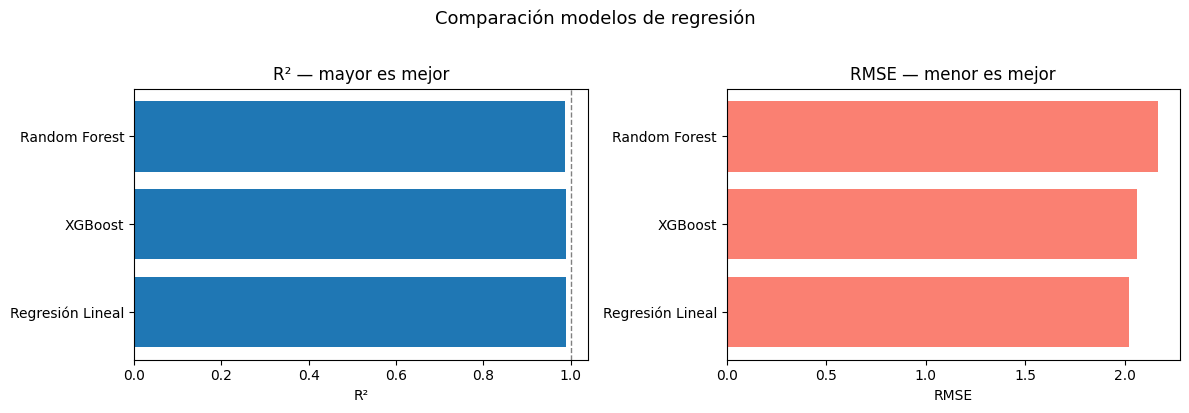

In [125]:
resultados_reg = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Random Forest", "XGBoost"],
    "R²":     [r2_score(y_reg_test, pred_lr),
               r2_score(y_reg_test, pred_rf_reg),
               r2_score(y_reg_test, pred_xgb_reg)],
    "RMSE":   [np.sqrt(mean_squared_error(y_reg_test, pred_lr)),
               np.sqrt(mean_squared_error(y_reg_test, pred_rf_reg)),
               np.sqrt(mean_squared_error(y_reg_test, pred_xgb_reg))]
}).sort_values("R²", ascending=False).reset_index(drop=True)

print(resultados_reg.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(resultados_reg["Modelo"], resultados_reg["R²"])
axes[0].set_title("R² — mayor es mejor")
axes[0].set_xlabel("R²")
axes[0].axvline(1, color="gray", ls="--", lw=1)

axes[1].barh(resultados_reg["Modelo"], resultados_reg["RMSE"], color="salmon")
axes[1].set_title("RMSE — menor es mejor")
axes[1].set_xlabel("RMSE")

plt.suptitle("Comparación modelos de regresión", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


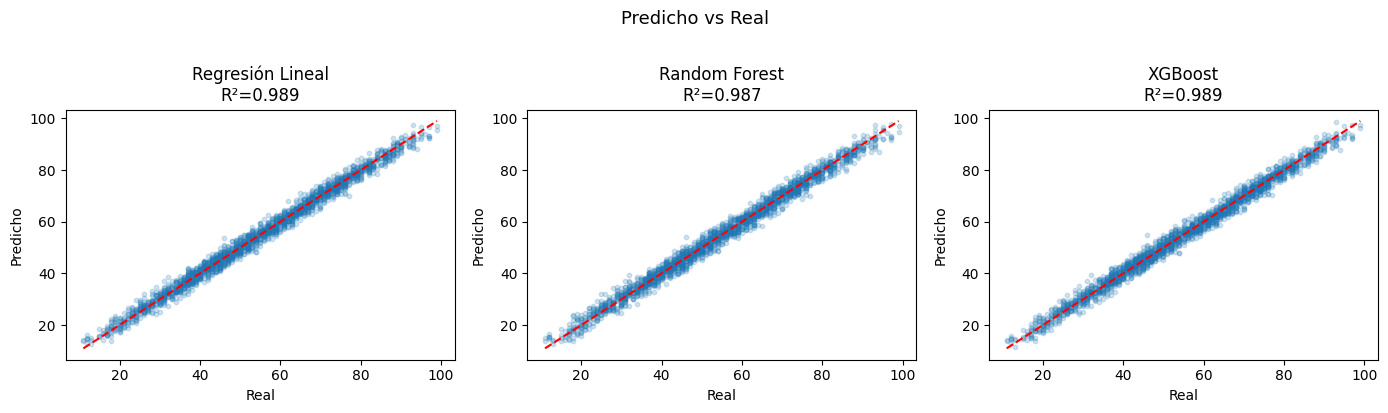

In [126]:
# Predicho vs Real
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, pred, nombre in zip(axes,
    [pred_lr, pred_rf_reg, pred_xgb_reg],
    ["Regresión Lineal", "Random Forest", "XGBoost"]):

    ax.scatter(y_reg_test, pred, alpha=0.2, s=10)
    lims = [y_reg_test.min(), y_reg_test.max()]
    ax.plot(lims, lims, color="red", lw=1.5, ls="--")
    ax.set_title(f"{nombre}\nR²={r2_score(y_reg_test, pred):.3f}")
    ax.set_xlabel("Real")
    ax.set_ylabel("Predicho")

plt.suptitle("Predicho vs Real", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



### 2.3.2 Modelo de Clasificación

**Objetivo:** identificar si un estudiante es de bajo rendimiento (1) o no (0).  

**Métrica principal: F1-score** — balancea precisión y recall, clave cuando nos importa no perder estudiantes en riesgo.  

**Validación:** StratifiedKFold con 5 splits (mantiene la proporción de clases en cada fold).

**Modelos:** Regresión logística, Random Forest, XGBoost

In [114]:
pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_log = {
    "model__C":        [0.01, 0.1, 1, 10],
    "model__penalty":  ["l1", "l2"],
    "model__solver":   ["liblinear"]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_log = GridSearchCV(pipe_log, param_grid_log,
                      cv=skf, scoring="f1", n_jobs=-1)
cv_log.fit(X_train_c, y_clf_train)

pred_log = cv_log.predict(X_test_c)

print("── Regresión Logística ──────────────────────")
print(f"Mejores parámetros : {cv_log.best_params_}")
print(f"\n{classification_report(y_clf_test, pred_log, target_names=['Normal/Alto','Bajo rendimiento'])}")


── Regresión Logística ──────────────────────
Mejores parámetros : {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

                  precision    recall  f1-score   support

     Normal/Alto       0.97      0.97      0.97       858
Bajo rendimiento       0.98      0.98      0.98      1142

        accuracy                           0.97      2000
       macro avg       0.97      0.97      0.97      2000
    weighted avg       0.97      0.97      0.97      2000



In [115]:
pipe_rf_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RandomForestClassifier(random_state=42))
])

param_grid_rf_clf = {
    "model__n_estimators": [100, 200],
    "model__max_depth":    [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

cv_rf_clf = GridSearchCV(pipe_rf_clf, param_grid_rf_clf,
                         cv=skf, scoring="f1", n_jobs=-1, verbose=0)
cv_rf_clf.fit(X_train_c, y_clf_train)

pred_rf_clf = cv_rf_clf.predict(X_test_c)

print("── Random Forest Classifier ─────────────────")
print(f"Mejores parámetros : {cv_rf_clf.best_params_}")
print(f"\n{classification_report(y_clf_test, pred_rf_clf, target_names=['Normal/Alto','Bajo rendimiento'])}")


── Random Forest Classifier ─────────────────
Mejores parámetros : {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}

                  precision    recall  f1-score   support

     Normal/Alto       0.97      0.96      0.97       858
Bajo rendimiento       0.97      0.98      0.97      1142

        accuracy                           0.97      2000
       macro avg       0.97      0.97      0.97      2000
    weighted avg       0.97      0.97      0.97      2000



In [116]:
pipe_xgb_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  XGBClassifier(random_state=42, verbosity=0,
                             eval_metric="logloss"))
])

param_grid_xgb_clf = {
    "model__n_estimators":  [100, 200],
    "model__max_depth":     [3, 5, 7],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__subsample":     [0.8, 1.0]
}

cv_xgb_clf = GridSearchCV(pipe_xgb_clf, param_grid_xgb_clf,
                           cv=skf, scoring="f1", n_jobs=-1, verbose=0)
cv_xgb_clf.fit(X_train_c, y_clf_train)

pred_xgb_clf = cv_xgb_clf.predict(X_test_c)

print("── XGBoost Classifier ───────────────────────")
print(f"Mejores parámetros : {cv_xgb_clf.best_params_}")
print(f"\n{classification_report(y_clf_test, pred_xgb_clf, target_names=['Normal/Alto','Bajo rendimiento'])}")


── XGBoost Classifier ───────────────────────
Mejores parámetros : {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}

                  precision    recall  f1-score   support

     Normal/Alto       0.97      0.97      0.97       858
Bajo rendimiento       0.97      0.98      0.98      1142

        accuracy                           0.97      2000
       macro avg       0.97      0.97      0.97      2000
    weighted avg       0.97      0.97      0.97      2000




**Métrica de selección: F1-score** de la clase Bajo rendimiento (clase 1).  
Se reportan también Accuracy, Precision, Recall y AUC-ROC para un análisis completo.


In [117]:
def metricas_clf(y_true, y_pred, y_prob):
    return {
        "F1":       f1_score(y_true, y_pred),
        "AUC-ROC":  roc_auc_score(y_true, y_prob),
        "Accuracy": (y_true == y_pred).mean(),
        "Precision": __import__("sklearn.metrics", fromlist=["precision_score"])
                     .precision_score(y_true, y_pred),
        "Recall":   __import__("sklearn.metrics", fromlist=["recall_score"])
                     .recall_score(y_true, y_pred),
    }

resultados_clf = pd.DataFrame({
    "Modelo": ["Reg. Logística", "Random Forest", "XGBoost"],
    **{k: [v] * 3 for k, v in {}.items()}
})

rows = []
for nombre, pipeline, pred in [
    ("Reg. Logística", cv_log,     pred_log),
    ("Random Forest",  cv_rf_clf,  pred_rf_clf),
    ("XGBoost",        cv_xgb_clf, pred_xgb_clf),
]:
    prob = pipeline.predict_proba(X_test_c)[:, 1]
    m = metricas_clf(y_clf_test, pred, prob)
    m["Modelo"] = nombre
    rows.append(m)

resultados_clf = pd.DataFrame(rows)[["Modelo","F1","AUC-ROC","Accuracy","Precision","Recall"]]
resultados_clf = resultados_clf.sort_values("F1", ascending=False).reset_index(drop=True)
print(resultados_clf.round(4).to_string(index=False))


        Modelo     F1  AUC-ROC  Accuracy  Precision  Recall
Reg. Logística 0.9772   0.9980    0.9740     0.9781  0.9764
       XGBoost 0.9768   0.9978    0.9735     0.9747  0.9790
 Random Forest 0.9747   0.9976    0.9710     0.9721  0.9772


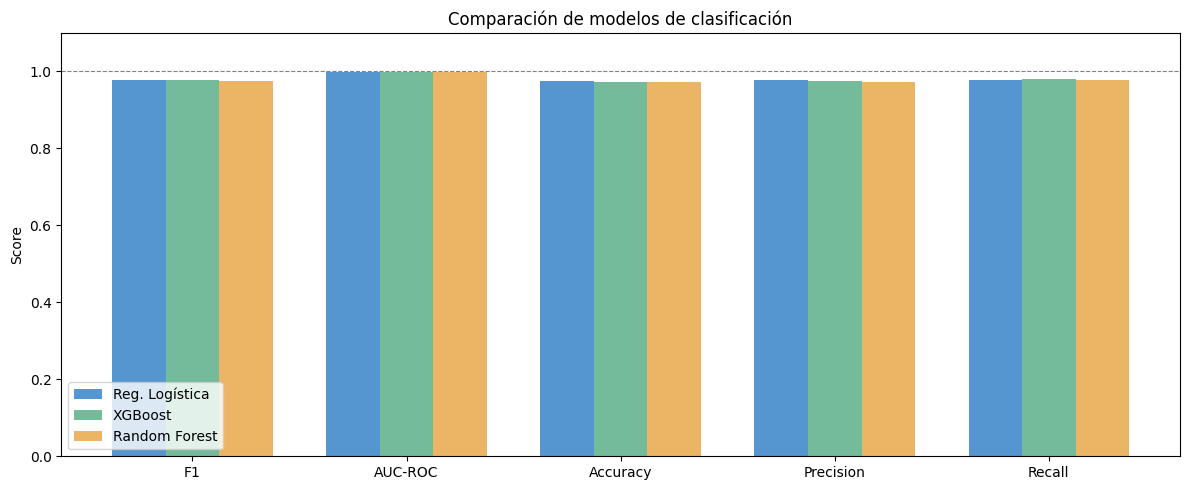

In [118]:
# Gráfico de métricas comparativas
metricas = ["F1", "AUC-ROC", "Accuracy", "Precision", "Recall"]
x = np.arange(len(metricas))
width = 0.25
colores = ["#3783c8", "#5bb08a", "#e9a84a"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, row) in enumerate(resultados_clf.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metricas],
           width, label=row["Modelo"], color=colores[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1)
ax.set_title("Comparación de modelos de clasificación")
ax.set_ylabel("Score")
ax.legend()
ax.axhline(1, color="gray", ls="--", lw=0.8)
plt.tight_layout()
plt.show()


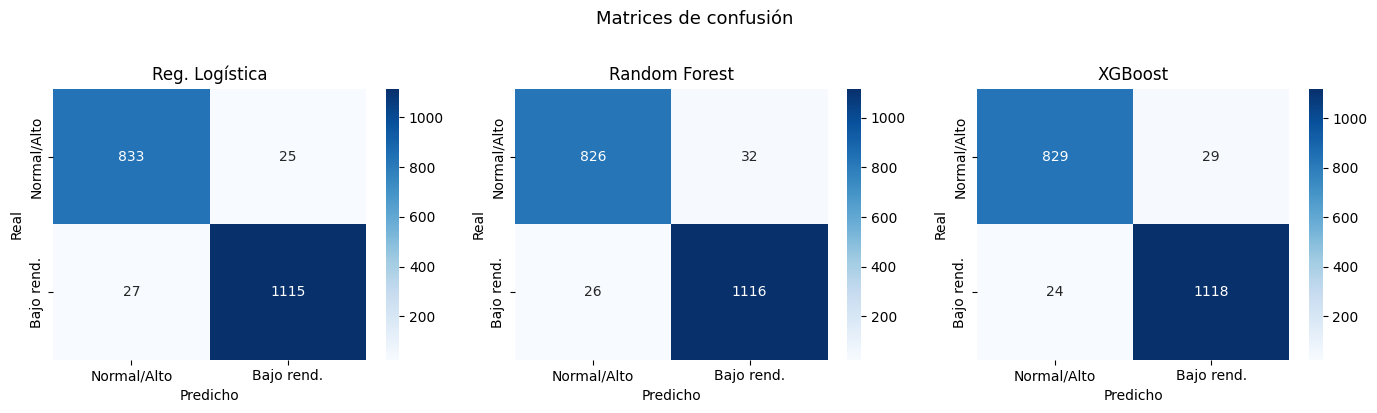

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, pred, nombre in zip(axes,
    [pred_log, pred_rf_clf, pred_xgb_clf],
    ["Reg. Logística", "Random Forest", "XGBoost"]):

    cm = confusion_matrix(y_clf_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal/Alto", "Bajo rend."],
                yticklabels=["Normal/Alto", "Bajo rend."])
    ax.set_title(nombre)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.suptitle("Matrices de confusión", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


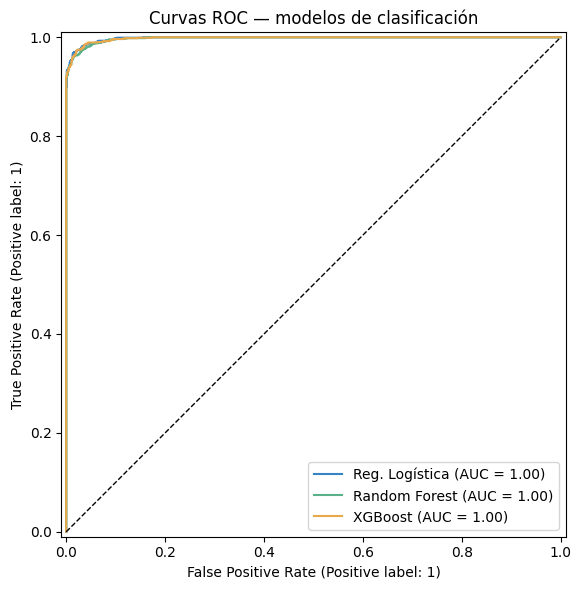

In [120]:
fig, ax = plt.subplots(figsize=(7, 6))

for pipeline, nombre, color in [
    (cv_log,     "Reg. Logística", "#3783c8"),
    (cv_rf_clf,  "Random Forest",  "#5bb08a"),
    (cv_xgb_clf, "XGBoost",        "#e9a84a"),
]:
    RocCurveDisplay.from_estimator(pipeline, X_test_c, y_clf_test,
                                   ax=ax, name=nombre, color=color)

ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_title("Curvas ROC — modelos de clasificación")
plt.tight_layout()
plt.show()


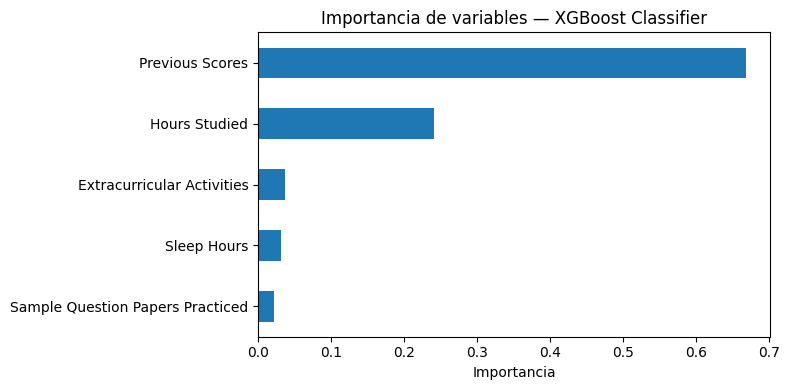

Previous Scores                     0.6676
Hours Studied                       0.2411
Extracurricular Activities          0.0370
Sleep Hours                         0.0321
Sample Question Papers Practiced    0.0223
dtype: float32


In [121]:
# Extraer importancias del modelo ganador (XGBoost)
importancias = cv_xgb_clf.best_estimator_.named_steps["model"].feature_importances_

fi = pd.Series(importancias, index=FEATURES).sort_values(ascending=True)

fi.plot(kind="barh", figsize=(8, 4))
plt.title("Importancia de variables — XGBoost Classifier")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

print(fi.sort_values(ascending=False).round(4))


### 2.3.3 Resumen final del modelado 

In [127]:
print("═" * 50)
print("  MODELOS DE REGRESIÓN")
print("═" * 50)
print(resultados_reg.round(4).to_string(index=False))

print()
print("═" * 50)
print("  MODELOS DE CLASIFICACIÓN")
print("═" * 50)
print(resultados_clf.round(4).to_string(index=False))

print()
print("── Decisión ─────────────────────────────────")
mejor_reg = resultados_reg.iloc[0]
mejor_clf = resultados_clf.iloc[0]
print(f"Mejor regresor    : {mejor_reg['Modelo']}  (R²={mejor_reg['R²']:.4f}, RMSE={mejor_reg['RMSE']:.4f})")
print(f"Mejor clasificador: {mejor_clf['Modelo']}  (F1={mejor_clf['F1']:.4f}, AUC={mejor_clf['AUC-ROC']:.4f})")


══════════════════════════════════════════════════
  MODELOS DE REGRESIÓN
══════════════════════════════════════════════════
          Modelo     R²   RMSE
Regresión Lineal 0.9890 2.0206
         XGBoost 0.9886 2.0595
   Random Forest 0.9873 2.1689

══════════════════════════════════════════════════
  MODELOS DE CLASIFICACIÓN
══════════════════════════════════════════════════
        Modelo     F1  AUC-ROC  Accuracy  Precision  Recall
Reg. Logística 0.9772   0.9980    0.9740     0.9781  0.9764
       XGBoost 0.9768   0.9978    0.9735     0.9747  0.9790
 Random Forest 0.9747   0.9976    0.9710     0.9721  0.9772

── Decisión ─────────────────────────────────
Mejor regresor    : Regresión Lineal  (R²=0.9890, RMSE=2.0206)
Mejor clasificador: Reg. Logística  (F1=0.9772, AUC=0.9980)
